# CS 3110/5110: Data Privacy
## In-Class Exercise, week of 9/14/2026

In [2]:
# Load the data and libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

adult = pd.read_csv('https://github.com/jnear/cs3110-data-privacy/raw/main/homework/adult_with_pii.csv')

In [3]:
df = adult[['Education', 'Marital Status', 'Target']]
df.head(10)

,Education,Marital Status,Target
0,Bachelors,Never-married,<=50K
1,Bachelors,Married-civ-spouse,<=50K
2,HS-grad,Divorced,<=50K
3,11th,Married-civ-spouse,<=50K
4,Bachelors,Married-civ-spouse,<=50K
5,Masters,Married-civ-spouse,<=50K
6,9th,Married-spouse-absent,<=50K
7,HS-grad,Married-civ-spouse,>50K
8,Masters,Never-married,>50K
9,Bachelors,Married-civ-spouse,>50K


## Question 6

Imagine the column `Target` is *not* a quasi-identifier, and we generalize the dataset to achieve $k$-Anonymity for $k=2$ as follows:

- Replace each education level below "HS Grad" with `< HS` and others with `>= HS`
- Replace marital status with `Married` and `Not Married`
- Delete rows as required to achieve $k$-anonymity for $k=2$

For which rows is a homogeneity attack possible, and why?

Any row where all values for a sensitive value are the same in a set of records. This is because the known values place the target in a specific group and that group membership reveals some new attribute.


## Question 7

Write code to generalize the `Zip` column in the adult dataset.

In [4]:
def generalize_zip(zip, l):
    return int(str(zip)[:-l] + '0' * l) if l else zip

In [5]:
# Test cases
assert generalize_zip(47401, 0) == 47401
assert generalize_zip(47401, 1) == 47400
assert generalize_zip(47401, 2) == 47400
assert generalize_zip(47401, 3) == 47000
assert generalize_zip(47401, 4) == 40000
assert generalize_zip(47401, 5) == 0

## Question 1

Write a *counting query* to determine whether or not Karrie Trusslove's age is 39.

In [6]:
# YOUR CODE HERE
def karrie_query():
    return len(adult[(adult['Name'] == 'Karrie Trusslove') & (adult['Age'] == 39)])

In [7]:
# TEST CASE 

assert karrie_query() == 1

## Question 2

Add Laplace noise to the counting query you wrote in the last question to ensure differential privacy for $\epsilon = 1.0$.

In [10]:
# YOUR CODE HERE
# Obscures whether or not the answer is 0 or 1 by adding random noise
# The problem is that we return the wrong answer
def dp_karrie_query():
    orignal_result = karrie_query()
    noise = np.random.laplace(loc=1, scale=1)
    return orignal_result + noise



In [11]:
# TEST CASE 

q2_runs = [dp_karrie_query() for _ in range(100)]
epsilon = 1
noise_runs = [np.random.laplace(loc=1, scale=1/epsilon) for _ in range(100)]

assert stats.wasserstein_distance(q2_runs, noise_runs) < 1

## Question 3

In 2-4 sentences, describe how `dp_karrie_query` protects Karrie's privacy.

dp_karrie_query protects Karrie's privacy by adding random noise to here data. This works by making her information inaccurate so that  specific information can not be gained and linking attacks can't be easily done.  

In [ ]:
"""
The original query is adversarially constructed to violate Karrie's privacy
The answer is 1 if Karrie is 39 and 0 otherwise
The noise introduces uncertainity for an aversary who wants to guess where the answer was 0 or 1 based on the DP result
More noise makes the uncertainty greater
The noise (thus the uncertainity) is independent from the data, the adversary can't undo the noise using the auxiliary information
"""

## Question 4

Implement a function to construct an *empirical distribution* over random samples from the Laplace distribution with location 0 and scale `scale`. Use 1000 samples.

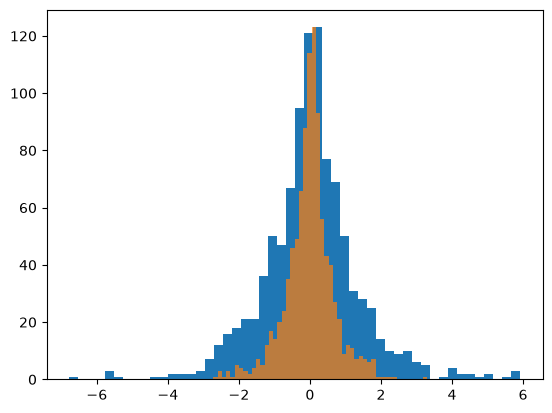

In [ ]:
def empirical_dist_lap(scale):
    samples = [np.random.laplace(loc=0, scale=scale) for _ in range(1000)]
    return samples

epsilon1 = 1.0
epsilon2 = 2.0

plt.hist(empirical_dist_lap(1/epsilon1), bins=50, label = 'epsilon 1');
plt.hist(empirical_dist_lap(1/epsilon2), bins=50, alpha=.7, label = 'epsilon 2');

In [ ]:
# PLACEHOLDER for test cases


## Question 5

Consider the program below.

In [ ]:
counting_query = lambda: 1

result_1 = counting_query() + np.random.laplace(loc=0, scale=1/epsilon1)
result_2 = counting_query() + np.random.laplace(loc=0, scale=1/epsilon2)
result_3 = counting_query() + np.random.laplace(loc=0, scale=1/epsilon1)

print(result_1, result_2, result_3)

Write a function `total_epsilon` that returns the total privacy cost for this program.

In [ ]:
def total_epsilon():
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
# Placeholder for test case
